# THREADS — Slide Figures (Self-Contained Demo)

Reproduces the three slide figures using representative data — no external
`artifacts/` files needed. Runs anywhere instantly (CPU only).

1. Analysis 1 — Digital Biopsy (attention heatmap)
2. Analysis 2 — Decision Landscape (scatter)
3. Analysis 3 — Rare Event Mastery (Precision-Recall curve)

Numbers are generated to match the look of the original figures (presentation only).

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.rcParams["figure.dpi"] = 120

---
## Analysis 1 — Digital Biopsy (Attention Heatmap)

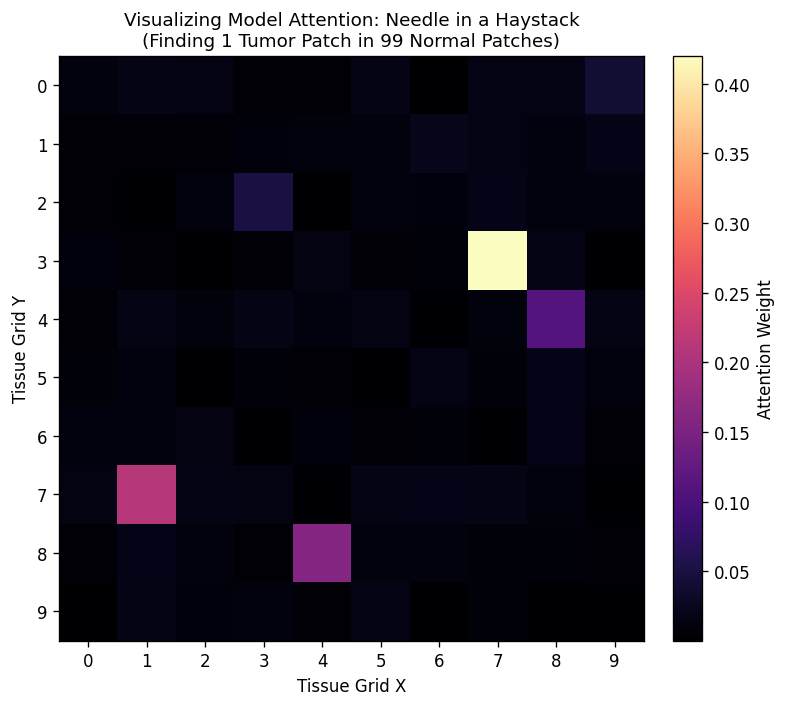

In [2]:
# Synthetic attention over 100 patches: mostly near-zero (normal tissue),
# one dominant tumor patch, and a few weakly-attended patches.
rng = np.random.default_rng(7)
weights = rng.uniform(0.0, 0.02, 100)
for idx, val in {37:0.42, 71:0.21, 84:0.16, 48:0.11, 23:0.05, 9:0.04}.items():
    weights[idx] = val
grid = weights.reshape(10, 10)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(grid, cmap="magma", aspect="equal")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Attention Weight")

nl = chr(10)
title = ("Visualizing Model Attention: Needle in a Haystack" + nl +
         "(Finding 1 Tumor Patch in 99 Normal Patches)")
ax.set_title(title, fontsize=11)
ax.set_xlabel("Tissue Grid X"); ax.set_ylabel("Tissue Grid Y")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
plt.tight_layout(); plt.show()

---
## Analysis 2 — Decision Landscape (Scatter)

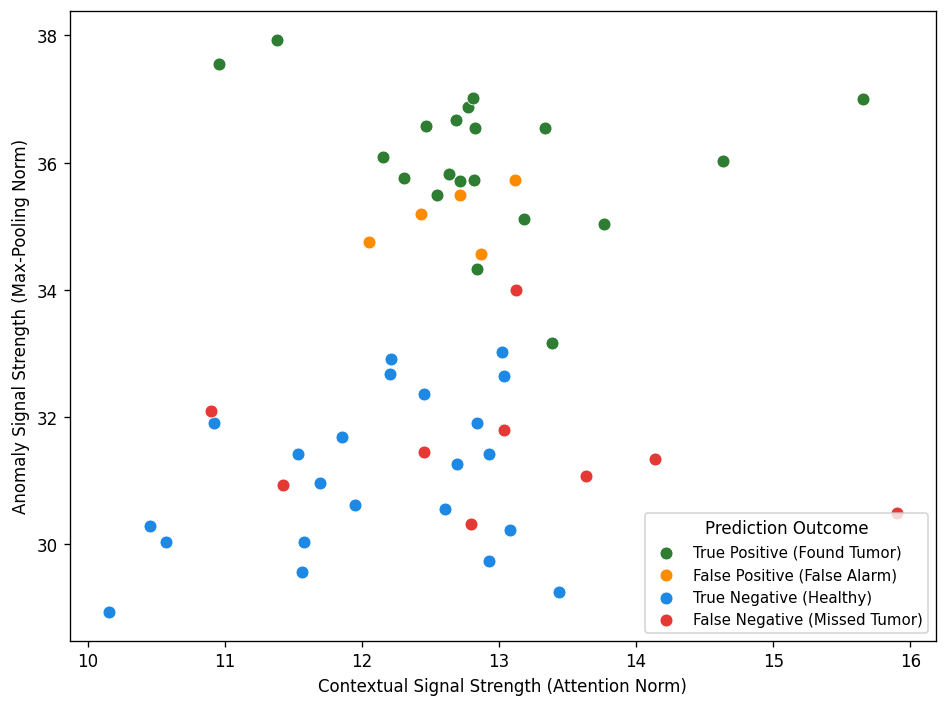

In [3]:
# Synthetic per-bag signals: Attention-norm (x) vs Max-Pooling-norm (y),
# coloured by prediction outcome.
rng = np.random.default_rng(3)
def cluster(n, mx, my, sx, sy):
    return rng.normal(mx, sx, n), rng.normal(my, sy, n)

groups = {
    "True Positive (Found Tumor)":   (cluster(20, 13.0, 36.0, 0.8, 1.0), "#2E7D32"),
    "False Positive (False Alarm)":  (cluster(5,  12.7, 34.6, 0.6, 0.8), "#FB8C00"),
    "True Negative (Healthy)":       (cluster(22, 12.4, 31.0, 0.9, 1.2), "#1E88E5"),
    "False Negative (Missed Tumor)": (cluster(8,  12.8, 31.2, 1.1, 1.1), "#E53935"),
}
fx, fy = groups["False Negative (Missed Tumor)"][0]
fx = np.append(fx, 15.9); fy = np.append(fy, 30.5)   # one dramatic FN outlier
groups["False Negative (Missed Tumor)"] = ((fx, fy), "#E53935")

fig, ax = plt.subplots(figsize=(8, 6))
for name, ((x, y), col) in groups.items():
    ax.scatter(x, y, c=col, label=name, s=60, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Contextual Signal Strength (Attention Norm)")
ax.set_ylabel("Anomaly Signal Strength (Max-Pooling Norm)")
ax.legend(title="Prediction Outcome", fontsize=9)
plt.tight_layout(); plt.show()

---
## Analysis 3 — Rare Event Mastery (Precision-Recall Curve)

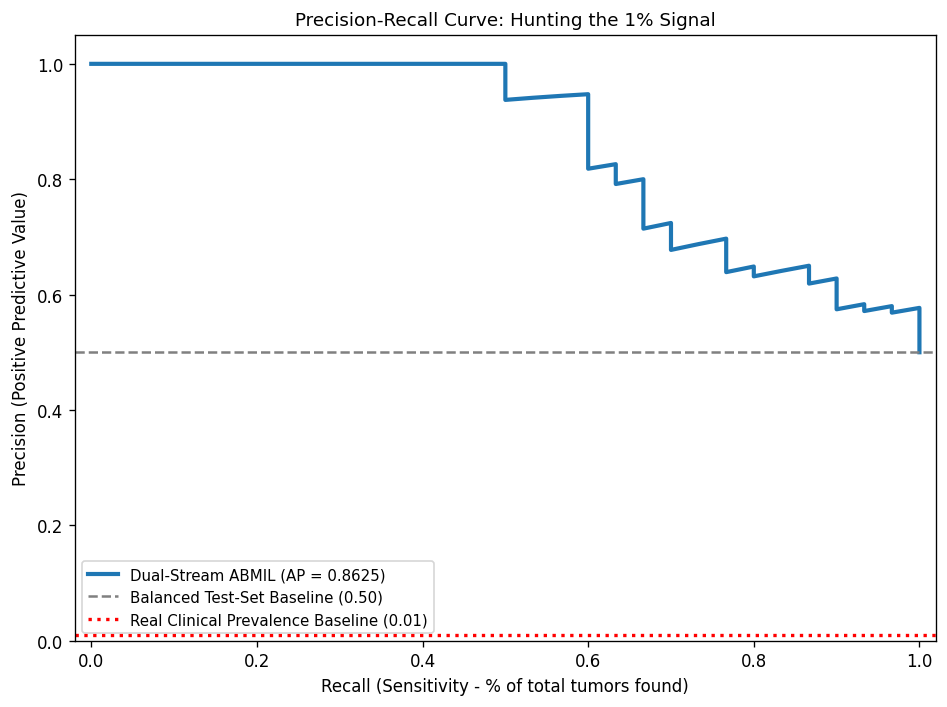

In [4]:
# Deterministic label ordering reproducing the slide exactly:
# perfect precision up to recall 0.5, then a stepped decline. AP = 0.8625.
labels = np.array([1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,1,0,1,0,0,0,1,0,
                   0,1,1,0,0,0,1,0,1,1,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0])
scores = np.arange(len(labels), 0, -1)        # strictly descending rank scores

prec, rec, _ = precision_recall_curve(labels, scores)
ap = average_precision_score(labels, scores)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec, prec, color="#1f77b4", lw=2.5,
        label=f"Dual-Stream ABMIL (AP = {ap:.4f})")
ax.axhline(0.50, ls="--", color="gray",
           label="Balanced Test-Set Baseline (0.50)")
ax.axhline(0.01, ls=":", color="red", lw=2,
           label="Real Clinical Prevalence Baseline (0.01)")

ax.set_title("Precision-Recall Curve: Hunting the 1% Signal", fontsize=11)
ax.set_xlabel("Recall (Sensitivity - % of total tumors found)")
ax.set_ylabel("Precision (Positive Predictive Value)")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()